# ENG EMG - how they are different


Extract window - feature and compare the T-test for each subject








In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import scipy, os
from sklearn.metrics import confusion_matrix
import seaborn as sns

import sys
sys.path.append('../../Share/')
sys.path.append('../../Share/Manual_processing/')
import baseline, config, Model, utils, Same_with_MATLAB, Feature_info

import warnings
warnings.filterwarnings('ignore')


def restore_labels(mat, labels_windowed):

    original_length = mat['Data_ADC'].shape[1]
    win_size = 1000 #Original
    win_step = 50
    #valid_length = original_length - 2 * 60

    label_full = np.zeros(original_length, dtype=labels_windowed.dtype) # 복원될 시계열 레이블 (원본 길이)

    # 슬라이딩 윈도우 인덱스 따라 레이블 채워넣기
    for i, label in enumerate(labels_windowed):
        start = 60 + i * win_step
        end = start + win_size
        if end <= original_length - 60:
            label_full[start:end] = label

    return label_full


def filtering_zero(X, y, erase_label):
    # 1. erase_label 제거
    keep_indices = y != erase_label
    X = X[keep_indices]
    y = y[keep_indices]

    # 2. erase_label보다 큰 값은 1씩 감소
    y = np.where(y > erase_label, y - 1, y)

    return X, y


from collections import Counter

def balance_data(X, y):
    # Count samples per class
    class_counts = Counter(y)
    min_count = min(class_counts.values())  # target: balance all to minority count

    indices_list = []

    for label in sorted(class_counts.keys()):
        label_indices = np.where(y == label)[0]
        selected_indices = np.random.choice(label_indices, size=min_count, replace=False)
        indices_list.extend(selected_indices)

    # Shuffle all selected indices
    balanced_indices = np.random.permutation(indices_list)

    # Subset the data
    X_balanced = X[balanced_indices]
    y_balanced = y[balanced_indices]

    return X_balanced, y_balanced

In [3]:
def return_X_y(path, balance):
    fs, lower_cutoff, upper_cutoff = Feature_info.fs, Feature_info.lower_cutoff, Feature_info.upper_cutoff
    # fs, lower_cutoff, upper_cutoff = Feature_info.fs, 1, 300
    filter_b, filter_a = Same_with_MATLAB.cheby2(4, 30, [lower_cutoff / (fs/2), upper_cutoff / (fs/2)], btype='bandpass')

    data_per_class_files = os.listdir(path)
    X, y = [], []

    for cls in data_per_class_files:
        input_path = path+cls+'/'
        files = os.listdir(input_path)
        mat = scipy.io.loadmat(input_path+files[0])
        label = mat['Data_Cls'].reshape(-1)  # shape: (1, 1729)

        feat_mean = np.tile(Feature_info.feat_mean_lst, (4, 1))
        feat_std = np.tile(Feature_info.feat_std_lst, (4, 1))

        mapped_label = np.where(label == 0, 0, int(cls))
        restored_label = restore_labels(mat, mapped_label)

        #print(mat['Data_ADC'].shape, mat['Data_Cls'].shape, restored_label.shape)
        extractor = Same_with_MATLAB.EMGFeatureExtractor(feat_mean, feat_std, filter_b, filter_a, Norm_bool=False, num_feature_set=14) #I tried 23, but not so good
        extractor.buffer = mat['Data_ADC']
        #1000, 50 = winsize and winstep
        features, labels = extractor.extract_features_with_labels(win_size=1000, win_step=50, feat_exclude=25, filtering=False, restored_label=restored_label)

        features = np.transpose(features, (2, 0, 1))  # shape: (1729, 4, 14)
        X.append(features)
        y.append(labels)
        #print(features.shape, labels.shape)

    X_train = np.concatenate(X, axis=0)
    y_train = np.concatenate(y, axis=0)
    #X_train = X_train[:, :, :, np.newaxis]

    #print(pd.Series(y_train).value_counts())
    #print(X_train.shape, y_train.shape)

    if balance:
        X_train, y_train = balance_data(X_train, y_train)

    # X_train, y_train = filtering_zero(X_train, y_train, erase_label=0)  ####이거하면 길이가 달라져 버림
    # One_X_train = X_train[:, :, feature_idx, :]

    return X_train, y_train



def run(subject, modality):
    if modality == 'EMG': bluetooth_id = 'E8DD80E550BB'
    elif modality == 'ENG': bluetooth_id = 'E9AD0E7DCC2B'
    else:
        print("Modality should be EMG or ENG")
        return

    X_v1, y_v1 = return_X_y(path = base_path+f'{subject}/{modality}_v1/{bluetooth_id}/raw/', balance=False)
    X_v2, y_v2 = return_X_y(path = base_path+f'{subject}/{modality}_v2/{bluetooth_id}/raw/', balance=False)

    return X_v1, y_v1, X_v2, y_v2


from scipy.stats import ttest_rel
feature_names = ['Zero Crossing (ZC)', 'Slope Sign Changes (SSC)', 'Waveform Length (WL)', 'WAMP', 'Mean Absolute Value (MAV)', 'Mean Square (MS)',
                     'Root Mean Square (RMS)', 'v-order 3 (V3)', 'log detector (LD)', 'difference absolute standard deviation value (DASDV)', 'maximum fractal length (MFL)', 'myopulse percentage rate (MPR)', 'mean absolute value slope (MAVS)', 'weighted mean absolute (WMS)']

def get_T_test(X_ENG, y_ENG, X_EMG, y_EMG):

    gestures = np.unique(y_EMG)

    results = []

    for g in gestures:
        idx_emg = np.where(y_EMG == g)[0]
        idx_eng = np.where(y_ENG == g)[0]

        Xg_emg = X_EMG[idx_emg]  # shape: (samples, channels, features)
        Xg_eng = X_ENG[idx_eng]
        #print(Xg_emg.shape, Xg_eng.shape)

        for f, fname in enumerate(feature_names):

            if Xg_emg[:, :, f].shape == Xg_eng[:, :, f].shape:
                #print("flatten")
                data_emg = Xg_emg[:, :, f].flatten()
                data_eng = Xg_eng[:, :, f].flatten()

            else:
                #print("mean")
                data_emg = Xg_emg[:, :, f].mean(axis=1)
                data_eng = Xg_eng[:, :, f].mean(axis=1)

            # paired t-test (샘플 수 맞추기)
            min_len = min(len(data_emg), len(data_eng))
            t_stat, p_val = ttest_rel(data_emg[:min_len], data_eng[:min_len])

            # 평균 ± std
            mean_sd_emg = f"{data_emg[:min_len].mean():.3f} ± {data_emg[:min_len].std():.3f}"
            mean_sd_eng = f"{data_eng[:min_len].mean():.3f} ± {data_eng[:min_len].std():.3f}"

            results.append([fname, g, mean_sd_eng, mean_sd_emg, p_val])

    df = pd.DataFrame(results, columns=["Feature", "Gesture", "ENG (Mean±SD)", "EMG (Mean±SD)", "p-value"])
    return df #np.array(df)


import seaborn as sns

def heatmap_vis(df):
    # p-value만 matrix로 추출
    pivot = df.pivot(index='Feature', columns='Gesture', values='p-value')

    plt.figure(figsize=(8, 4))
    sns.heatmap(pivot, annot=True, cmap="coolwarm", center=0.05)  # 0.05 기준 색 변화
    plt.title("ENG vs EMG p-value per Feature and Gesture")
    plt.show()



In [4]:
base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/EMG_ENG/'
all_subject = []

In [5]:
base_path_tmp = 'C:/Users/hml76/PycharmProjects/MindForce/data/EMG_ENG/Hongjun/ENG_v1/E9AD0E7DCC2B/raw/'
data_per_class_files = os.listdir(base_path_tmp)
X = []

for cls in data_per_class_files:
    input_path = base_path_tmp+cls+'/'
    files = os.listdir(input_path)
    mat = scipy.io.loadmat(input_path+files[0])
    label = mat['Data_Cls'].reshape(-1)  # shape: (1, 1729)
    X.append(mat['Data_ADC'])

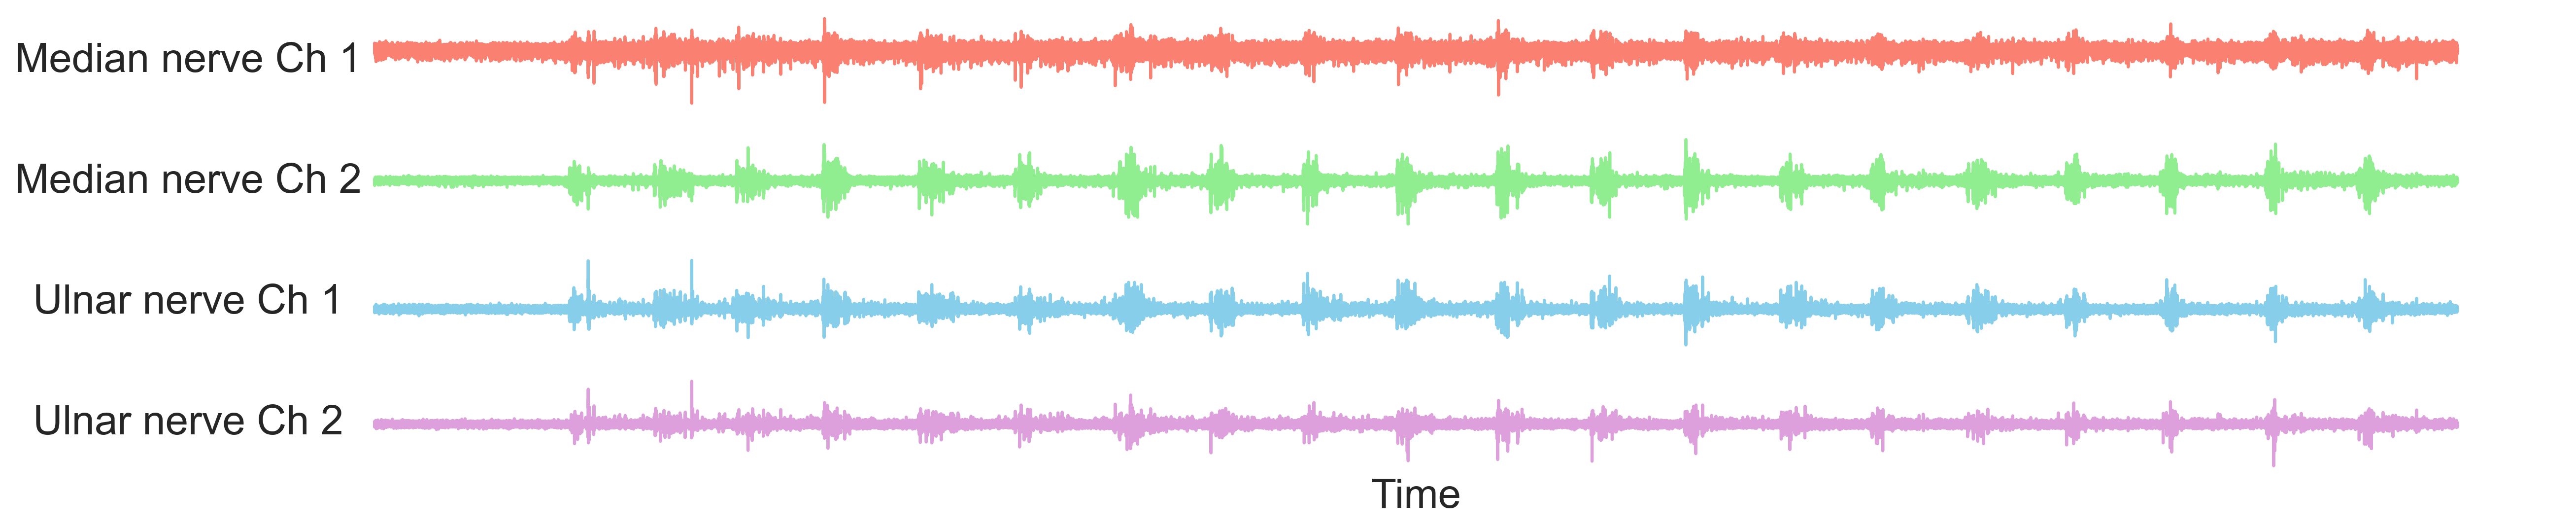

In [47]:
fig, axes = plt.subplots(4, 1, figsize=(20, 4), sharex=True, dpi=300)

colors = ['salmon', 'lightgreen', 'skyblue', 'plum'] #['orange', 'lightcoral', 'skyblue', 'darkblue']
#


for ch in range(4):
    axes[ch].plot(X[0][ch, 100:-2000], color=colors[ch])
    if ch < 2:
        label = f'Median nerve Ch {ch+1}'
    else:
        label = f'Ulnar nerve Ch {ch-1}'

    axes[ch].set_ylabel(label, rotation=0, labelpad=40, va='center', fontsize=20)

    # remove ticks and spines
    axes[ch].set_xticks([])
    axes[ch].set_yticks([])
    for spine in axes[ch].spines.values():
        spine.set_visible(False)

axes[-1].set_xlabel('Time', fontsize=20)

#plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()

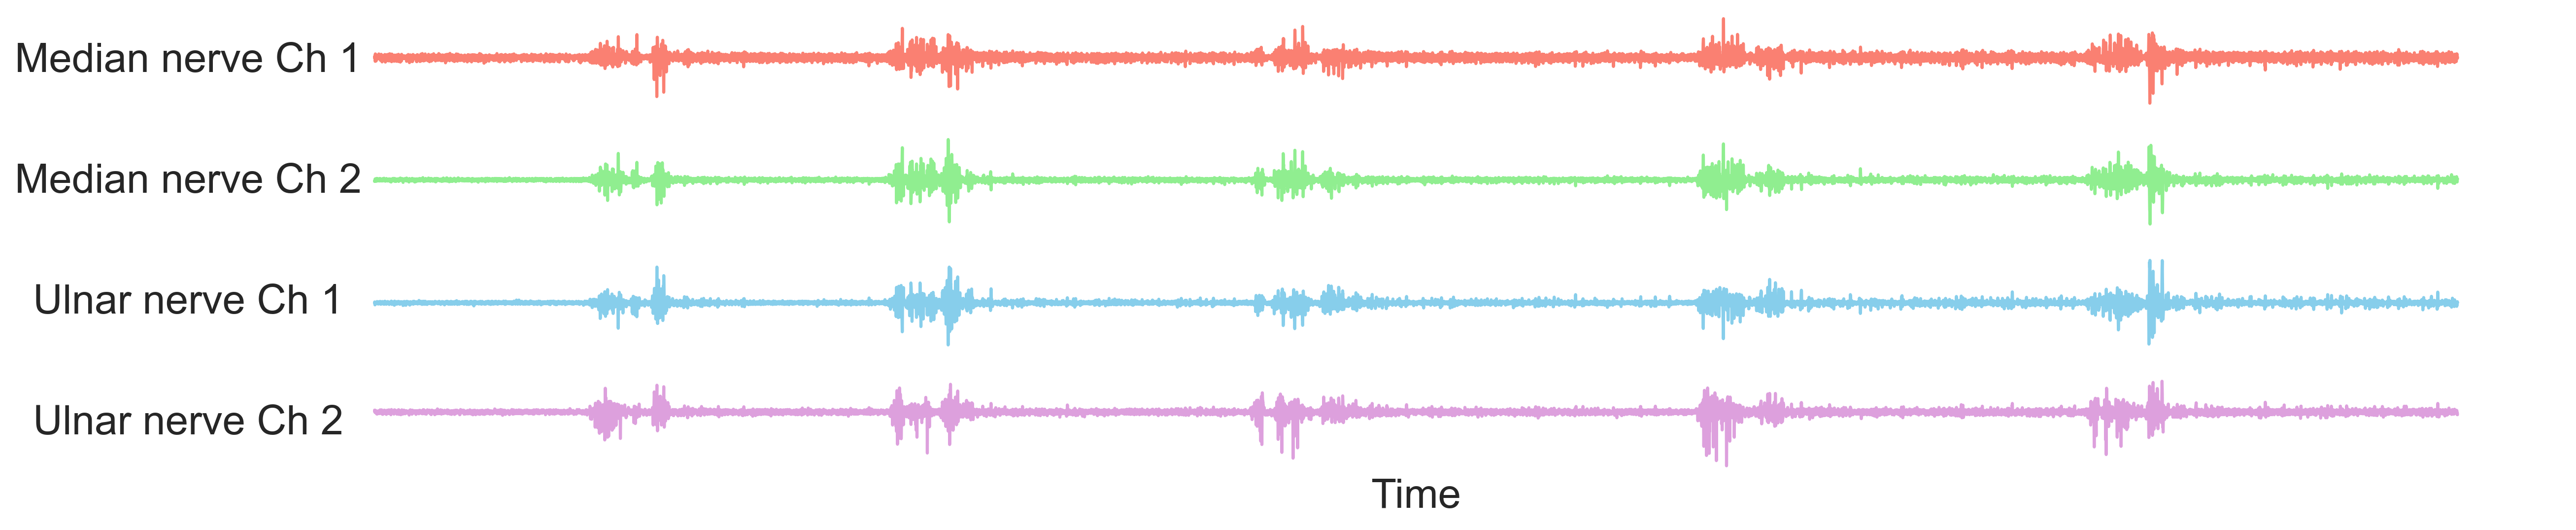

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(20, 4), sharex=True, dpi=300)

colors = ['salmon', 'lightgreen', 'skyblue', 'plum'] #['orange', 'lightcoral', 'skyblue', 'darkblue']
#


for ch in range(4):
    axes[ch].plot(X[1][ch, 15000:-150000], color=colors[ch])
    if ch < 2:
        label = f'Median nerve Ch {ch+1}'
    else:
        label = f'Ulnar nerve Ch {ch-1}'

    axes[ch].set_ylabel(label, rotation=0, labelpad=40, va='center', fontsize=20)

    # remove ticks and spines
    axes[ch].set_xticks([])
    axes[ch].set_yticks([])
    for spine in axes[ch].spines.values():
        spine.set_visible(False)

axes[-1].set_xlabel('Time', fontsize=20)

#plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()

In [16]:
#48sec
X_emg1, y_emg1, X_emg2, y_emg2 = run(subject='Hunmin', modality='EMG')
X_eng1, y_eng1, X_eng2, y_eng2 = run(subject='Hunmin', modality='ENG')

print(X_emg1.shape, X_eng1.shape, X_emg2.shape, X_eng2.shape)

all_heatmap = get_T_test(X_eng1, y_eng1, X_emg1, y_emg1)
#heatmap_vis(all_heatmap)

(34016, 4, 14) (33864, 4, 14) (34026, 4, 14) (33609, 4, 14)


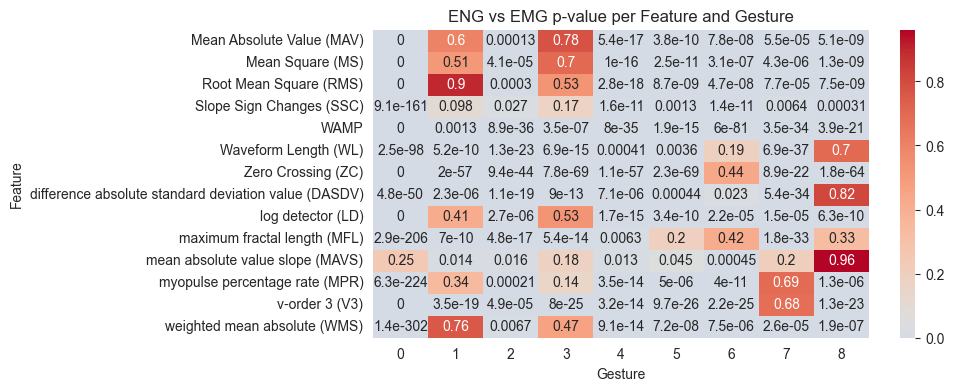

In [22]:
all_p_value = np.array(all_heatmap['p-value'])
heatmap_vis(all_heatmap)

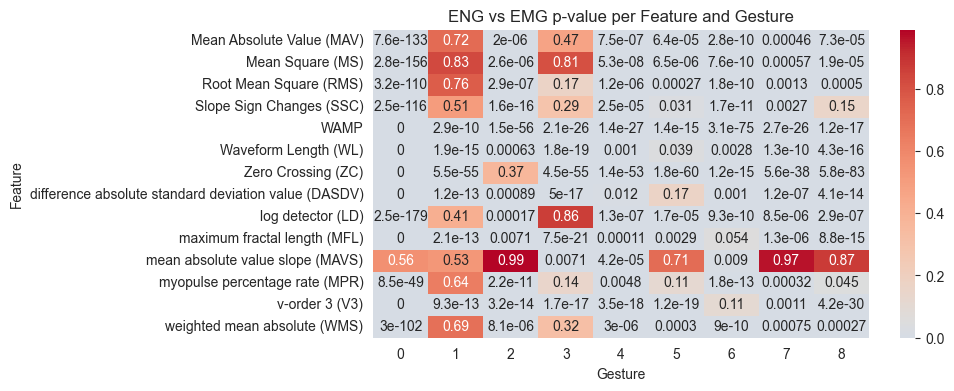

(126,)


In [25]:
df = get_T_test(X_eng2, y_eng2, X_emg2, y_emg2)
all_p_value = all_p_value + np.array(df['p-value'])
heatmap_vis(df)
print(all_p_value.shape)

(34110, 4, 14) (34016, 4, 14) (34080, 4, 14) (34057, 4, 14)


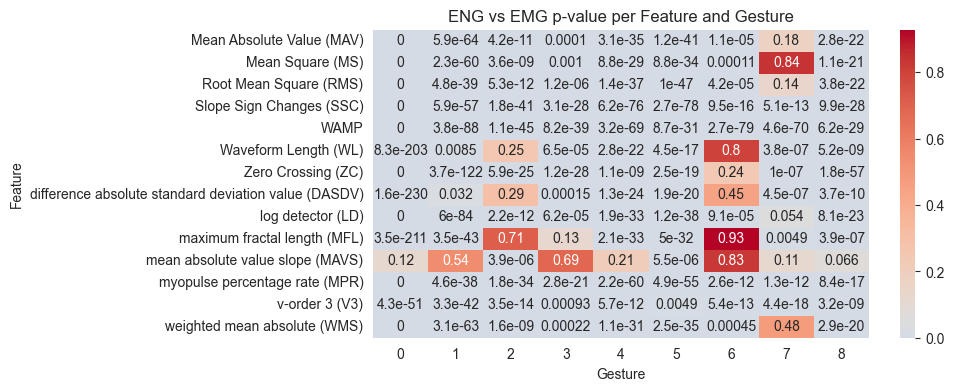

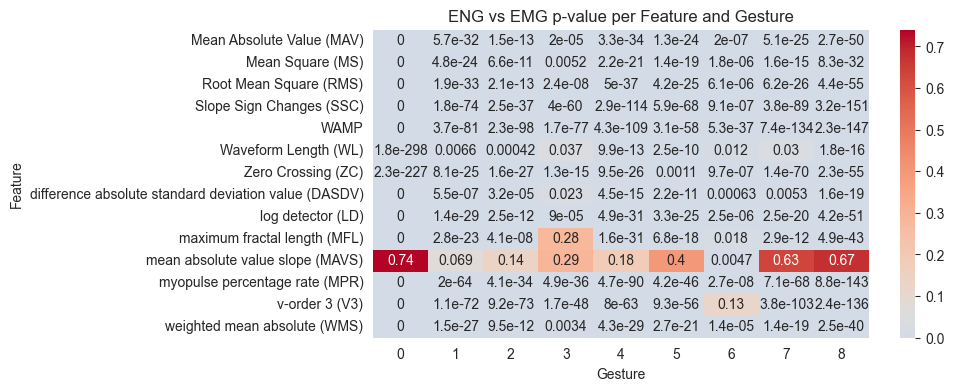

In [26]:
SUB = 'Hongjun'
X_emg1, y_emg1, X_emg2, y_emg2 = run(subject=SUB, modality='EMG')
X_eng1, y_eng1, X_eng2, y_eng2 = run(subject=SUB, modality='ENG')

print(X_emg1.shape, X_eng1.shape, X_emg2.shape, X_eng2.shape)

df = get_T_test(X_eng1, y_eng1, X_emg1, y_emg1)
all_p_value = all_p_value + np.array(df['p-value'])
heatmap_vis(df)

df = get_T_test(X_eng2, y_eng2, X_emg2, y_emg2)
all_p_value = all_p_value + np.array(df['p-value'])
heatmap_vis(df)

(33690, 4, 14) (34026, 4, 14) (34049, 4, 14) (34058, 4, 14)


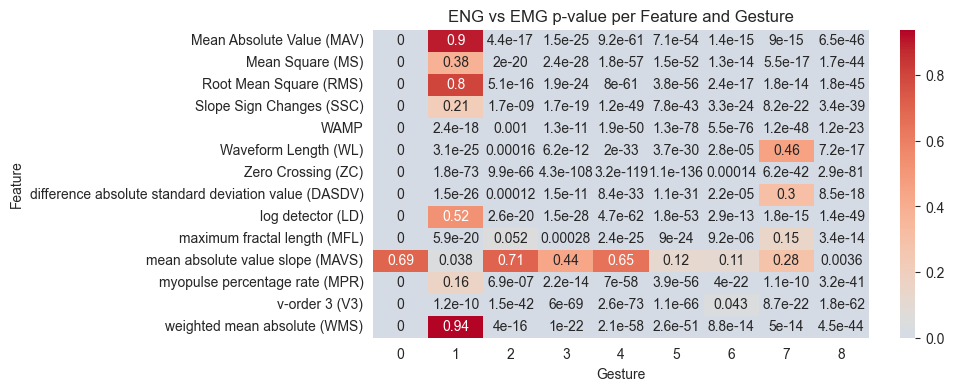

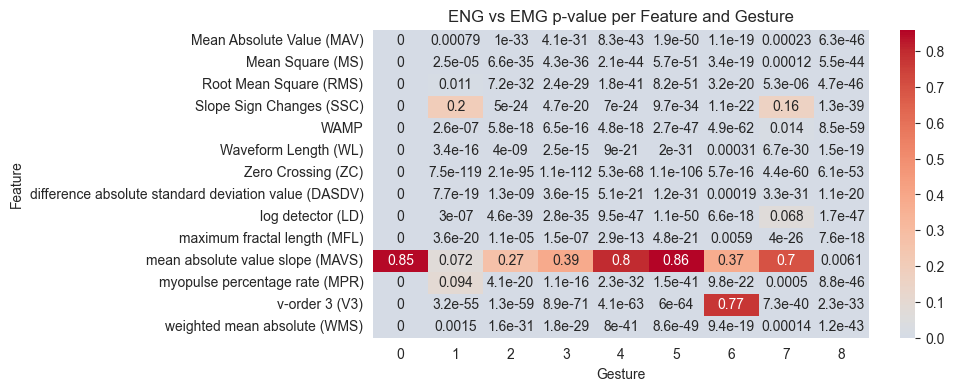

In [27]:
SUB = 'Jongin'
X_emg1, y_emg1, X_emg2, y_emg2 = run(subject=SUB, modality='EMG')
X_eng1, y_eng1, X_eng2, y_eng2 = run(subject=SUB, modality='ENG')

print(X_emg1.shape, X_eng1.shape, X_emg2.shape, X_eng2.shape)

df = get_T_test(X_eng1, y_eng1, X_emg1, y_emg1)
all_p_value = all_p_value + np.array(df['p-value'])
heatmap_vis(df)

df = get_T_test(X_eng2, y_eng2, X_emg2, y_emg2)
all_p_value = all_p_value + np.array(df['p-value'])
heatmap_vis(df)

(34122, 4, 14) (34017, 4, 14) (34089, 4, 14) (34046, 4, 14)


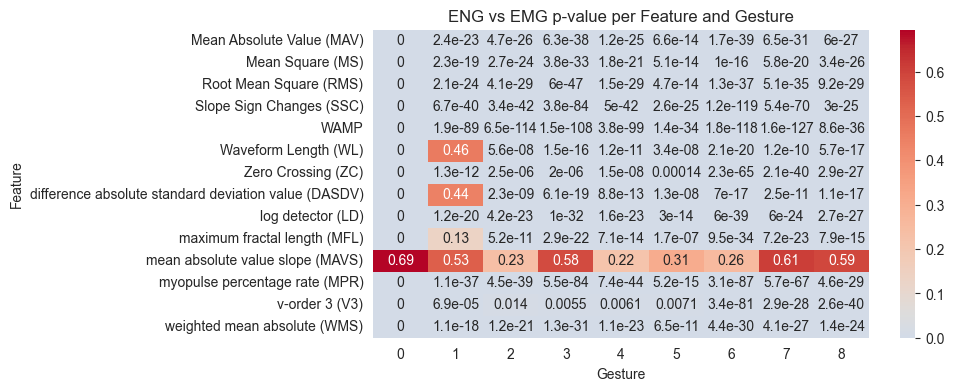

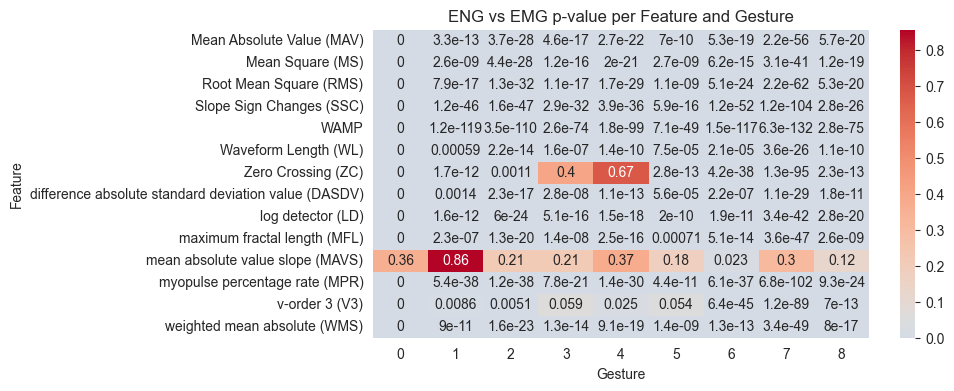

In [28]:
SUB = 'Byeongchan'
X_emg1, y_emg1, X_emg2, y_emg2 = run(subject=SUB, modality='EMG')
X_eng1, y_eng1, X_eng2, y_eng2 = run(subject=SUB, modality='ENG')

print(X_emg1.shape, X_eng1.shape, X_emg2.shape, X_eng2.shape)

df = get_T_test(X_eng1, y_eng1, X_emg1, y_emg1)
all_p_value = all_p_value + np.array(df['p-value'])
heatmap_vis(df)

df = get_T_test(X_eng2, y_eng2, X_emg2, y_emg2)
all_p_value = all_p_value + np.array(df['p-value'])
heatmap_vis(df)

(33895, 4, 14) (34068, 4, 14) (29982, 4, 14) (34016, 4, 14)


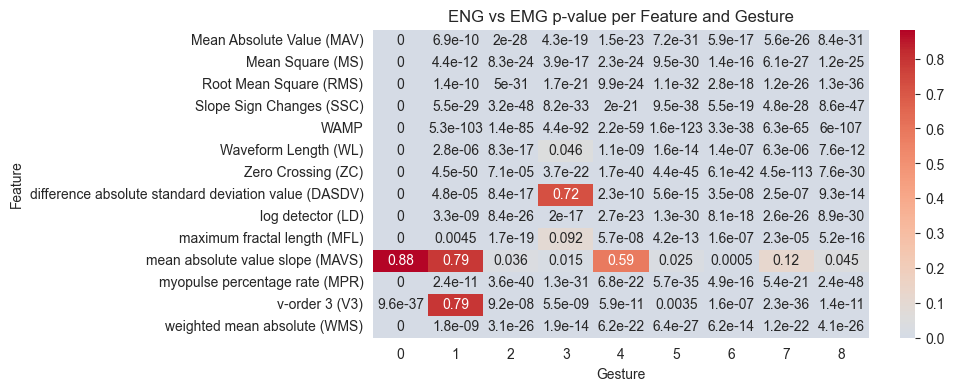

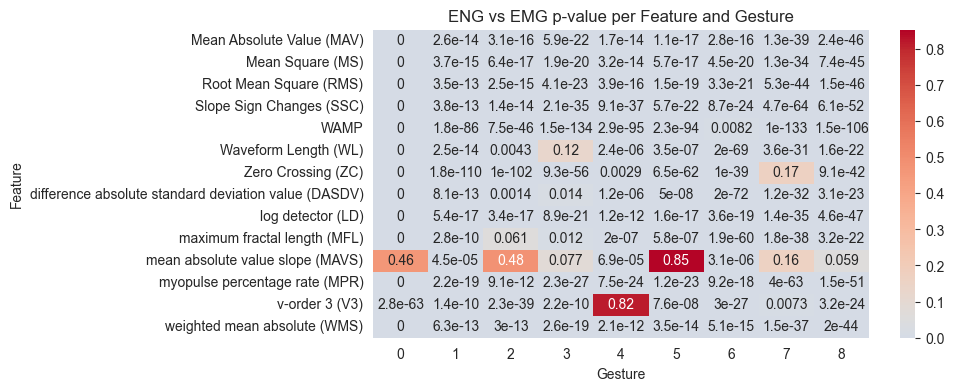

In [29]:
SUB = 'Youngchul'
X_emg1, y_emg1, X_emg2, y_emg2 = run(subject=SUB, modality='EMG')
X_eng1, y_eng1, X_eng2, y_eng2 = run(subject=SUB, modality='ENG')

print(X_emg1.shape, X_eng1.shape, X_emg2.shape, X_eng2.shape)

df = get_T_test(X_eng1, y_eng1, X_emg1, y_emg1)
all_p_value = all_p_value + np.array(df['p-value'])
heatmap_vis(df)

df = get_T_test(X_eng2, y_eng2, X_emg2, y_emg2)
all_p_value = all_p_value + np.array(df['p-value'])
heatmap_vis(df)

(33997, 4, 14) (33926, 4, 14) (33926, 4, 14) (33915, 4, 14)


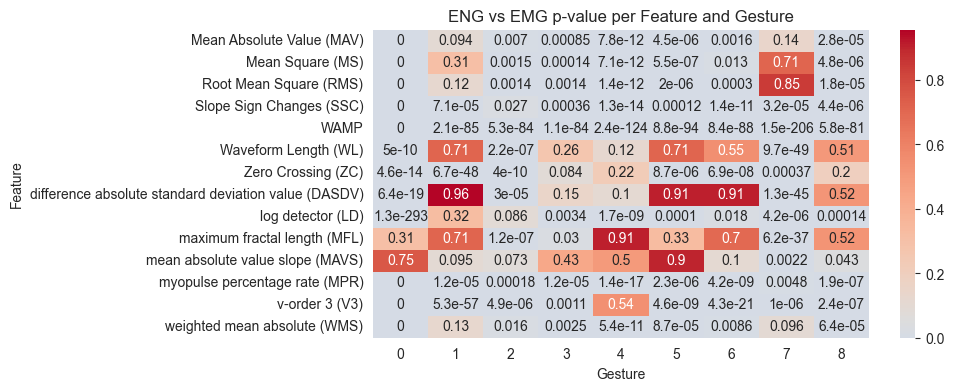

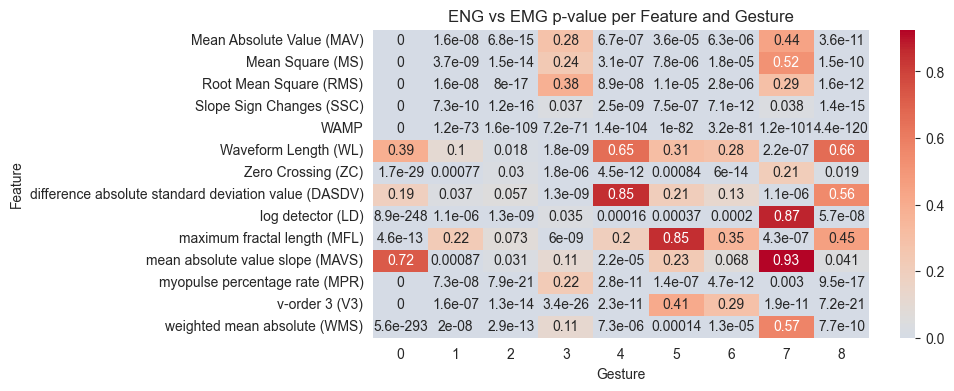

In [30]:
SUB = 'Minjeong'
X_emg1, y_emg1, X_emg2, y_emg2 = run(subject=SUB, modality='EMG')
X_eng1, y_eng1, X_eng2, y_eng2 = run(subject=SUB, modality='ENG')

print(X_emg1.shape, X_eng1.shape, X_emg2.shape, X_eng2.shape)

df = get_T_test(X_eng1, y_eng1, X_emg1, y_emg1)
all_p_value = all_p_value + np.array(df['p-value'])
heatmap_vis(df)

df = get_T_test(X_eng2, y_eng2, X_emg2, y_emg2)
all_p_value = all_p_value + np.array(df['p-value'])
heatmap_vis(df)

(33864, 4, 14) (33852, 4, 14) (33730, 4, 14) (34016, 4, 14)


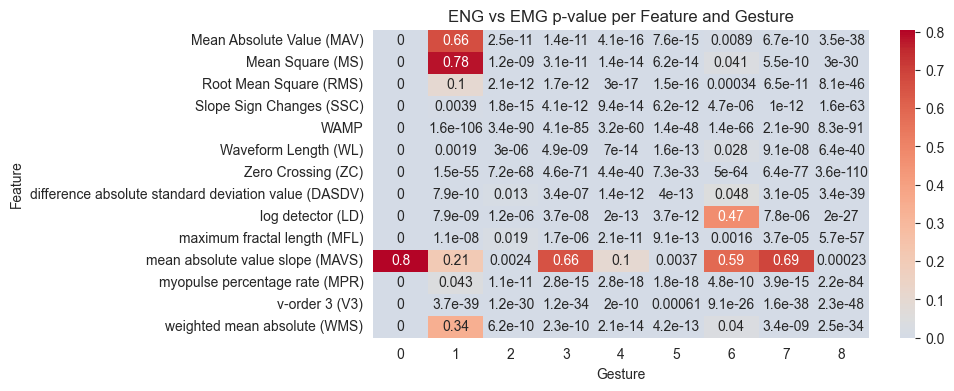

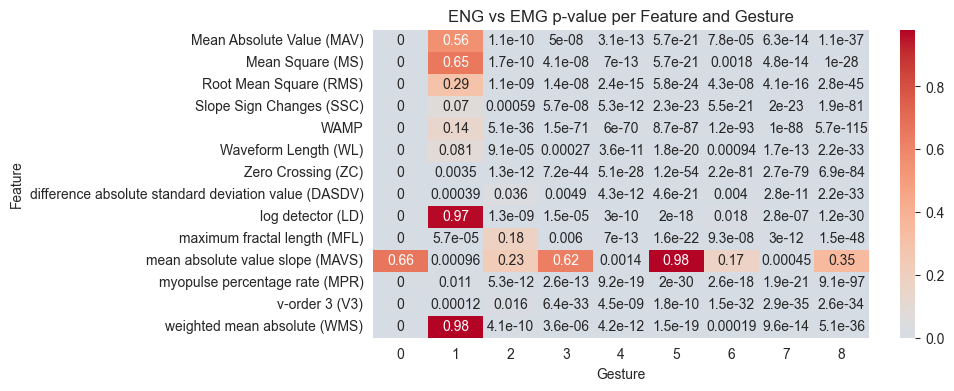

In [31]:
SUB = 'Harold'
X_emg1, y_emg1, X_emg2, y_emg2 = run(subject=SUB, modality='EMG')
X_eng1, y_eng1, X_eng2, y_eng2 = run(subject=SUB, modality='ENG')

print(X_emg1.shape, X_eng1.shape, X_emg2.shape, X_eng2.shape)

df = get_T_test(X_eng1, y_eng1, X_emg1, y_emg1)
all_p_value = all_p_value + np.array(df['p-value'])
heatmap_vis(df)

df = get_T_test(X_eng2, y_eng2, X_emg2, y_emg2)
all_p_value = all_p_value + np.array(df['p-value'])
heatmap_vis(df)

(33709, 4, 14) (33865, 4, 14) (33628, 4, 14) (33896, 4, 14)


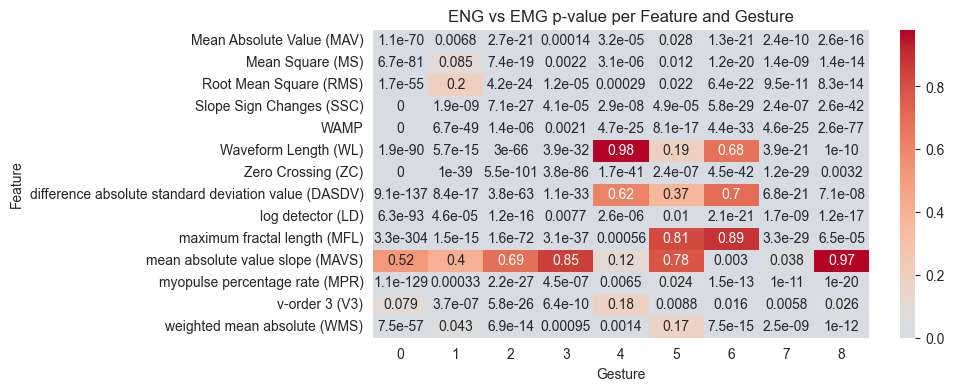

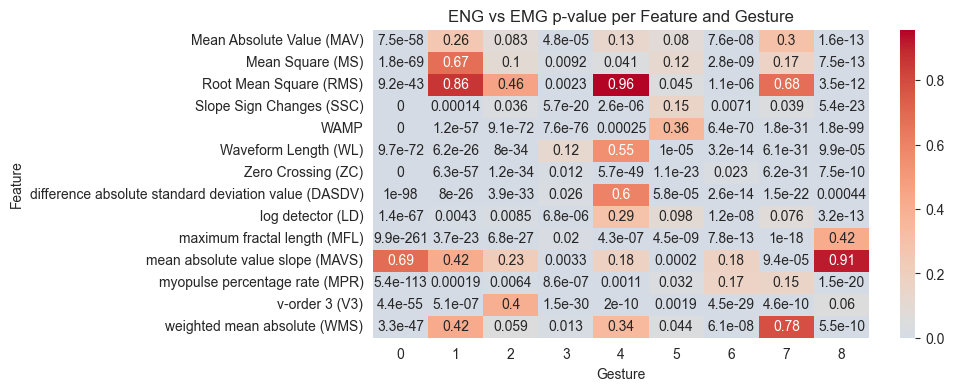

In [32]:
SUB = 'Xianyu'
X_emg1, y_emg1, X_emg2, y_emg2 = run(subject=SUB, modality='EMG')
X_eng1, y_eng1, X_eng2, y_eng2 = run(subject=SUB, modality='ENG')

print(X_emg1.shape, X_eng1.shape, X_emg2.shape, X_eng2.shape)

df = get_T_test(X_eng1, y_eng1, X_emg1, y_emg1)
all_p_value = all_p_value + np.array(df['p-value'])
heatmap_vis(df)

df = get_T_test(X_eng2, y_eng2, X_emg2, y_emg2)
all_p_value = all_p_value + np.array(df['p-value'])
heatmap_vis(df)

(33945, 4, 14) (33996, 4, 14) (33751, 4, 14) (33966, 4, 14)


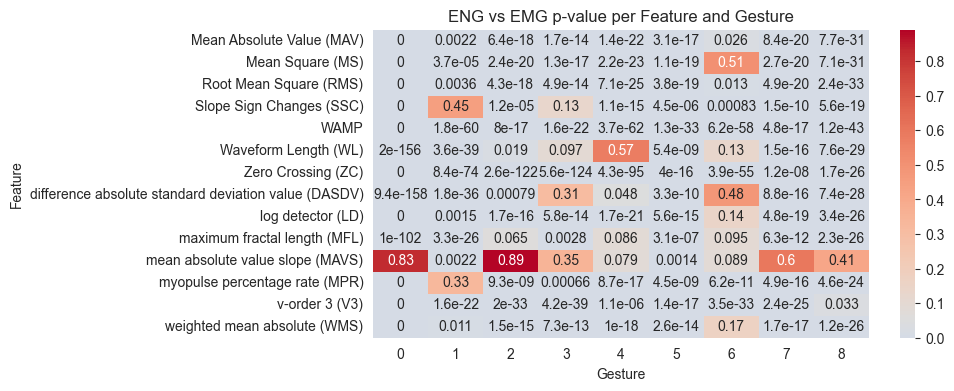

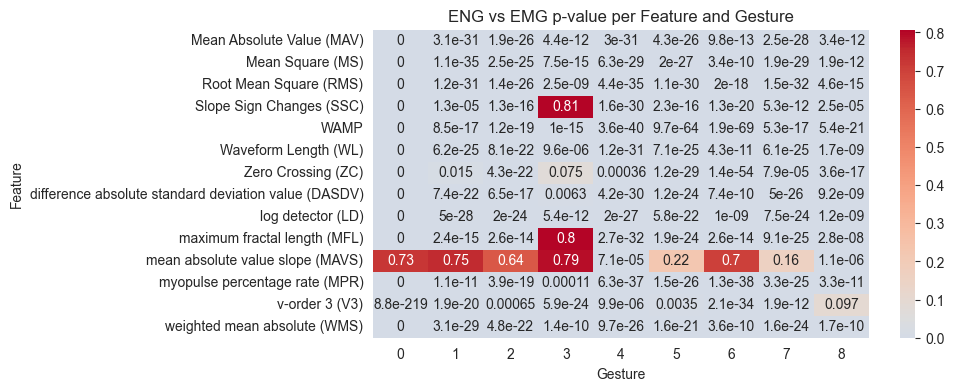

In [33]:
SUB = 'Carlson'
X_emg1, y_emg1, X_emg2, y_emg2 = run(subject=SUB, modality='EMG')
X_eng1, y_eng1, X_eng2, y_eng2 = run(subject=SUB, modality='ENG')

print(X_emg1.shape, X_eng1.shape, X_emg2.shape, X_eng2.shape)

df = get_T_test(X_eng1, y_eng1, X_emg1, y_emg1)
all_p_value = all_p_value + np.array(df['p-value'])
heatmap_vis(df)

df = get_T_test(X_eng2, y_eng2, X_emg2, y_emg2)
all_p_value = all_p_value + np.array(df['p-value'])
heatmap_vis(df)

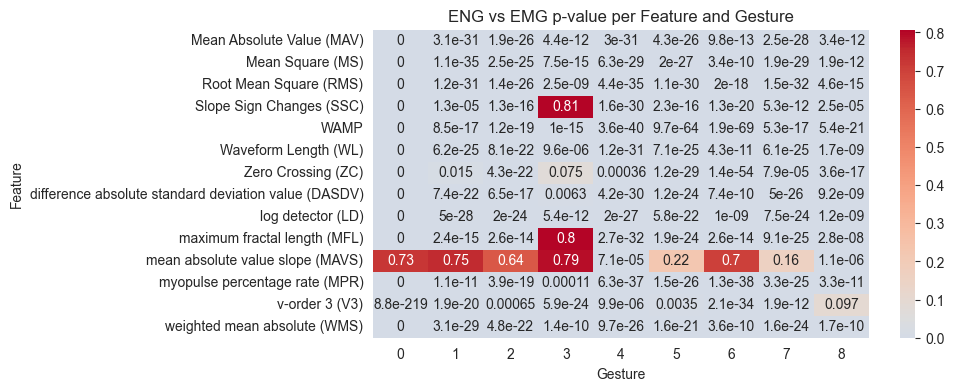

array([0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 8.81564370e-219,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       7.26703431e-001, 0.00000000e+000, 1.48230887e-002, 1.32359519e-005,
       6.22394511e-025, 8.48599637e-017, 3.07851243e-031, 1.05883645e-035,
       1.24007172e-031, 1.89555475e-020, 5.00419684e-028, 7.43935959e-022,
       2.42495119e-015, 1.10331110e-011, 7.47307481e-001, 3.07051349e-029,
       4.26180504e-022, 1.29597104e-016, 8.10122458e-022, 1.16289475e-019,
       1.87930606e-026, 2.51714219e-025, 1.41051839e-026, 6.45435089e-004,
       2.01565516e-024, 6.49271553e-017, 2.59577363e-014, 3.88866562e-019,
       6.36603383e-001, 4.79868066e-022, 7.50745143e-002, 8.06852681e-001,
       9.64316058e-006, 1.03174589e-015, 4.37263932e-012, 7.48711921e-015,
       2.50326419e-009, 5.92310994e-024, 5.41048413e-012, 6.32027703e-003,
       8.04458675e-001, 1

In [52]:

df2 = get_T_test(X_eng2, y_eng2, X_emg2, y_emg2)
heatmap_vis(df2)
np.array(df2['p-value'])

In [38]:
ave_p = all_p_value/18

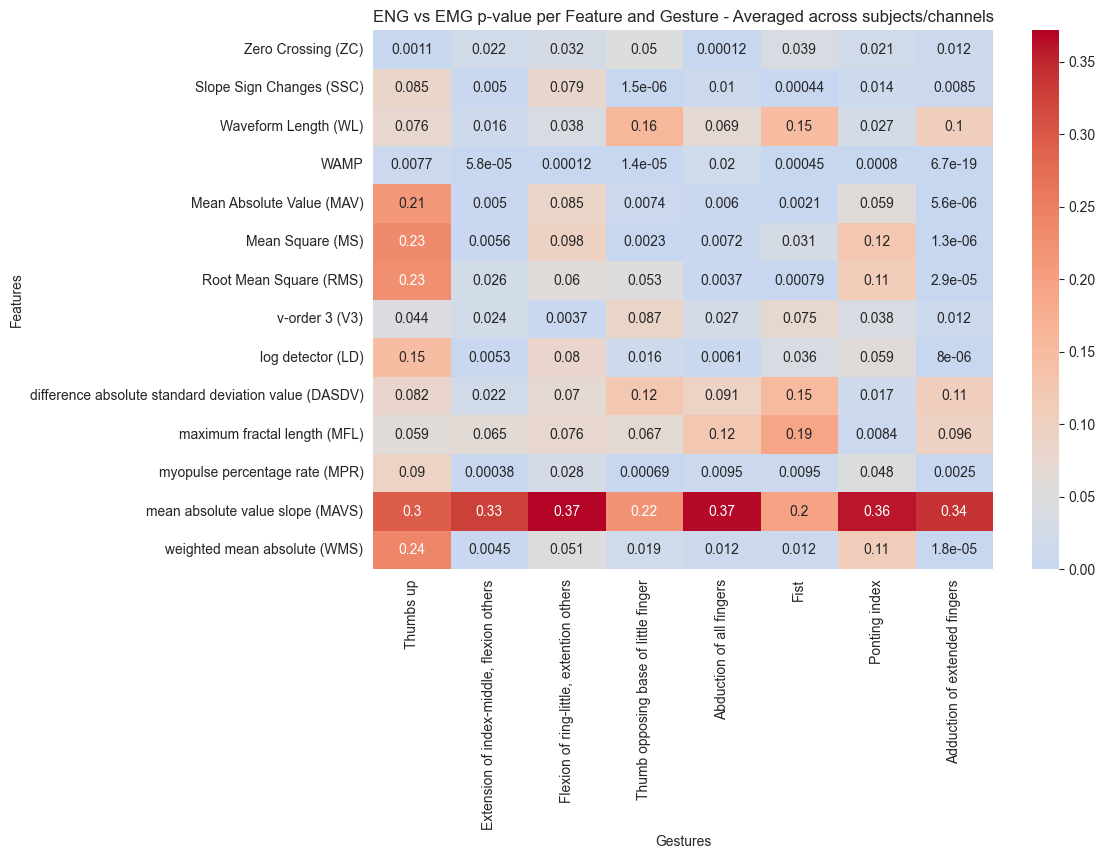

In [71]:
feature_names = ['Zero Crossing (ZC)', 'Slope Sign Changes (SSC)', 'Waveform Length (WL)', 'WAMP', 'Mean Absolute Value (MAV)', 'Mean Square (MS)',
                 'Root Mean Square (RMS)', 'v-order 3 (V3)', 'log detector (LD)', 'difference absolute standard deviation value (DASDV)', 'maximum fractal length (MFL)',
                 'myopulse percentage rate (MPR)', 'mean absolute value slope (MAVS)', 'weighted mean absolute (WMS)']

g_name = ['Thumbs up', 'Extension of index-middle, flexion others', 'Flexion of ring-little, extention others', 'Thumb opposing base of little finger', 'Abduction of all fingers', 'Fist', 'Ponting index', 'Adduction of extended fingers']

plt.figure(figsize=(10, 7))
sns.heatmap(
    np.array(ave_p).reshape(9,14).T[:,1:],
    annot=True,
    cmap="coolwarm",
    center=0.05,
    xticklabels=[f"{g}" for g in g_name],   # since you dropped [:,1:], that’s 8 gestures
    yticklabels=[f"{f}" for f in feature_names]
)
plt.title("ENG vs EMG p-value per Feature and Gesture - Averaged across subjects/channels")
plt.xlabel("Gestures")
plt.ylabel("Features")
plt.show()

In [59]:
ave_p

array([2.58170906e-015, 1.37390651e-117, 2.16547160e-002, 0.00000000e+000,
       4.15606949e-059, 1.00749056e-070, 5.11195684e-044, 4.36526437e-003,
       7.56289613e-069, 1.05107118e-002, 1.72531715e-002, 4.69785981e-050,
       6.28590300e-001, 1.85966475e-048, 1.05813249e-003, 8.51040925e-002,
       7.59668576e-002, 7.66262944e-003, 2.11034777e-001, 2.34528176e-001,
       2.25030667e-001, 4.44725827e-002, 1.47283327e-001, 8.16858761e-002,
       5.93778449e-002, 9.00925908e-002, 2.95642572e-001, 2.39692021e-001,
       2.22569708e-002, 5.03871198e-003, 1.63317798e-002, 5.76485604e-005,
       4.97990720e-003, 5.63623471e-003, 2.55423311e-002, 2.40379009e-002,
       5.28629539e-003, 2.23453867e-002, 6.51461309e-002, 3.78173863e-004,
       3.25563369e-001, 4.53935735e-003, 3.17658586e-002, 7.92656758e-002,
       3.80972074e-002, 1.18608644e-004, 8.48071793e-002, 9.83802662e-002,
       6.00913199e-002, 3.70778244e-003, 7.99532376e-002, 6.95789220e-002,
       7.64325072e-002, 2

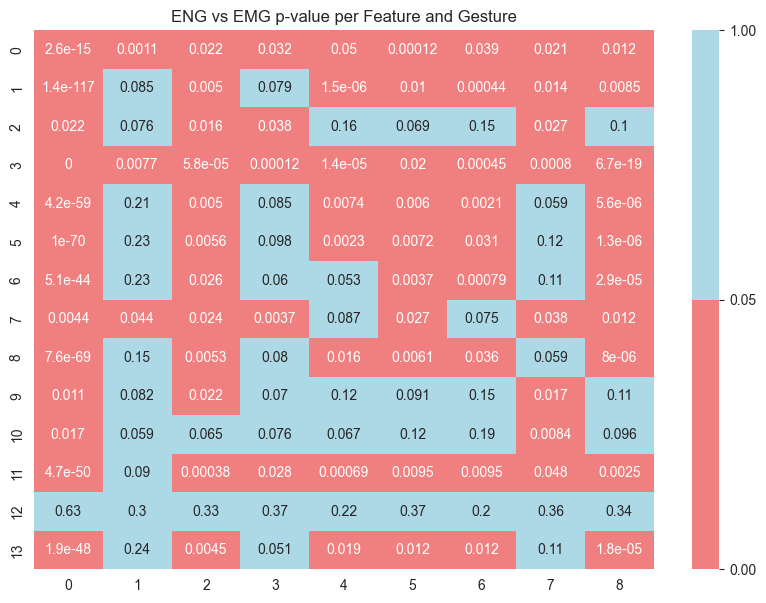

In [60]:
import matplotlib.colors as mcolors

# 0.05 기준으로 두 가지 색상만
cmap = mcolors.ListedColormap(["lightcoral", "lightblue"])
bounds = [0, 0.05, 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(10, 7))
sns.heatmap(
    np.array(ave_p).reshape(9, 14).T,
    annot=True,
    cmap=cmap,
    norm=norm,
    cbar_kws={"ticks": [0, 0.05, 1]}
)
plt.title("ENG vs EMG p-value per Feature and Gesture")
plt.show()


In [63]:
14*8, 47/112 #wl, 'difference absolute standard deviation value (DASDV)', 'maximum fractal length (MFL)', 'mean absolute value slope (MAVS)'

(112, 0.41964285714285715)

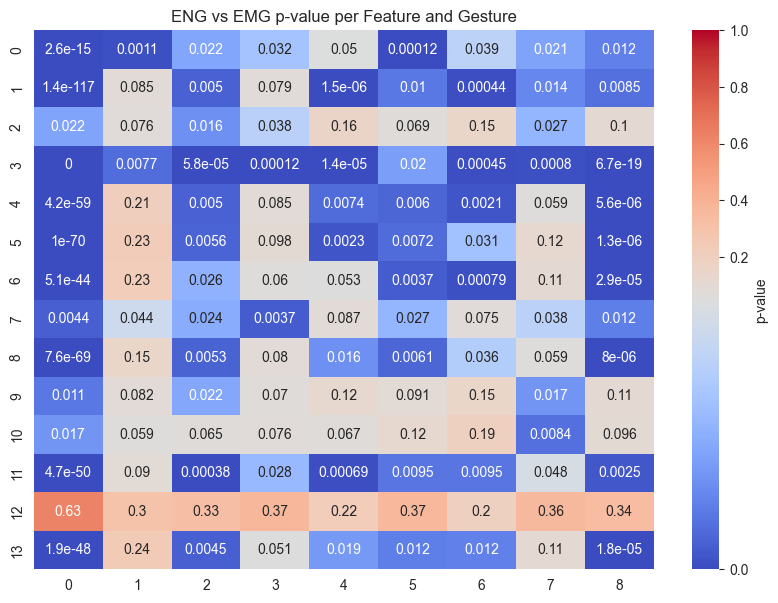

In [61]:
from matplotlib.colors import TwoSlopeNorm

vals = np.array(ave_p).reshape(9, 14).T

plt.figure(figsize=(10, 7))
sns.heatmap(
    vals,
    annot=True,
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=0, vcenter=0.05, vmax=1),
    cbar_kws={"label": "p-value"}
)
plt.title("ENG vs EMG p-value per Feature and Gesture")
plt.show()
